In [3]:
import warnings
import torch
import numpy as np
import SimpleITK as sitk

from torchio.transforms import RandomTransform

class RandomElasticDeformation(RandomTransform):
    """Apply random elastic deformations using BSplines."""
    def __init__(self, num_control_points=(7, 7, 7), max_displacement=7.5, locked_borders=2, image_interpolation='linear'):
        super().__init__()
        self.num_control_points = self._ensure_tuple(num_control_points, 3)
        self.max_displacement = self._ensure_tuple(max_displacement, 3)
        self.locked_borders = locked_borders
        self.image_interpolation = image_interpolation
        self.validate_parameters()

    def validate_parameters(self):
        if any(n < 4 for n in self.num_control_points):
            raise ValueError("num_control_points must be >= 4 in each dimension.")
        if any(d < 0 for d in self.max_displacement):
            raise ValueError("max_displacement must be non-negative.")
        if self.locked_borders not in (0, 1, 2):
            raise ValueError("locked_borders must be 0, 1, or 2.")

    @staticmethod
    def _ensure_tuple(value, length):
        if isinstance(value, (int, float)):
            return (value,) * length
        return tuple(value)

    def forward(self, image_tensor):
        # Simulate the deformation field
        control_point_grid_shape = self.num_control_points
        displacement_field = torch.rand(*control_point_grid_shape, 3) * 2 - 1  # range [-1, 1]
        displacement_field *= torch.tensor(self.max_displacement).view(1, 1, 1, 3)

        # Apply boundary conditions
        if self.locked_borders > 0:
            displacement_field[:, 0, :] = 0
            displacement_field[:, -1, :] = 0
            displacement_field[0, :, :] = 0
            displacement_field[-1, :, :] = 0

        # Apply BSpline interpolation and deformation to the image
        transformed_image = self.apply_bspline_deformation(image_tensor, displacement_field)
        return transformed_image

    def apply_bspline_deformation(self, image, displacement_field):
        # Placeholder for actual BSpline deformation code
        # For real implementation, convert to SimpleITK, apply BSplineTransform, and convert back
        return image  # This should be replaced with the actual transformed image




/home/mdi220/.virtualenvs/tvsb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'RandomTransform' from 'torchio.transforms' (/home/mdi220/.virtualenvs/tvsb/lib/python3.10/site-packages/torchio/transforms/__init__.py)

In [ ]:
# Example usage
transform = RandomElasticDeformation()
image = torch.randn(1, 1, 256, 256, 256)  # Simulated 3D image
transformed_image = transform(image)

In [4]:
import torchio as tio


In [8]:
# Create an instance of RandomElasticDeformation with more control points
elastic_deformation = tio.transforms.RandomElasticDeformation(
    num_control_points=(5, 5, 5),  # Increase number of control points
    max_displacement=(100, 100, 100),
    locked_borders=2,
)

# Load an image using torchio
subject = tio.datasets.Colin27()  # Sample dataset

# Apply the elastic deformation transform
transformed_subject = elastic_deformation(subject)

# Extracting and visualizing the transformed image
transformed_image = transformed_subject.t1


/home/mdi220/.virtualenvs/tvsb/lib/python3.10/site-packages/torchio/transforms/augmentation/spatial/random_elastic_deformation.py:303: RuntimeWarning: The maximum displacement is larger than the coarse grid spacing for dimensions: [0, 1, 2], so folding may occur. Choose fewer control points or a smaller maximum displacement
  self.parse_free_form_transform(


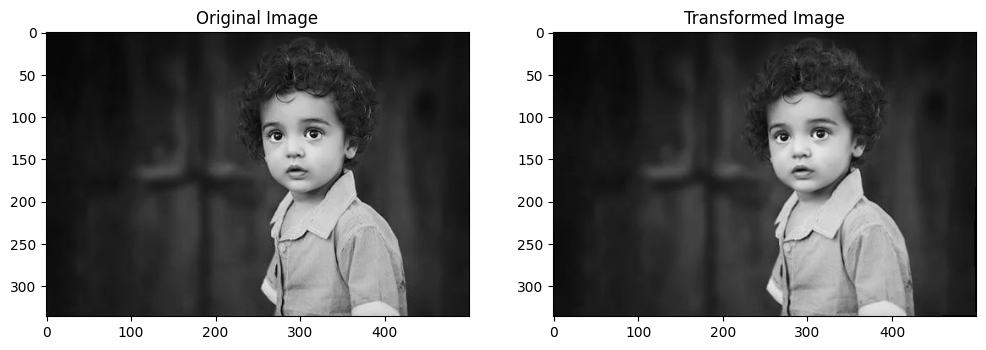

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchio as tio
from PIL import Image

# Load the 2D image using PIL and convert it to grayscale
image_path = 'image copy.png'
image_2d = Image.open(image_path).convert('L')  # Convert to grayscale
image_array = np.array(image_2d)

# Convert the 2D image array to a 4D array by adding channel and stacking slices
# We need to add a channel dimension to make it (C, D, H, W)
image_array_3d = np.stack([image_array] * 10, axis=0)  # Stack to make 3D (D, H, W)
image_array_4d = image_array_3d[np.newaxis, ...]  # Add channel dimension (C, D, H, W)

# Convert the numpy array to a torch tensor
image_tensor = torch.from_numpy(image_array_4d).float()

# Create a torchio ScalarImage
image_torchio = tio.ScalarImage(tensor=image_tensor)

# Create a subject with this image
subject = tio.Subject(my_image=image_torchio)

# Create the RandomElasticDeformation transform
elastic_deformation = tio.transforms.RandomElasticDeformation(
    num_control_points=7,
    max_displacement=10,
    locked_borders=2,
)

# Apply the elastic deformation transform
transformed_subject = elastic_deformation(subject)

# Extract the transformed image tensor for visualization
transformed_image = transformed_subject.my_image.tensor

# Correct way to get the middle index of the depth dimension
middle_slice_index = image_tensor.shape[1] // 2  # Correct axis for depth

plt.figure(figsize=(12, 6))
plt.subplot(121)
# Adjust the tensor slicing to match dimensions: channel, depth, height, width
plt.imshow(image_tensor[0, middle_slice_index, :, :], cmap='gray')  # Original Image
plt.title('Original Image')

plt.subplot(122)
plt.imshow(transformed_image[0, middle_slice_index, :, :], cmap='gray')  # Transformed Image
plt.title('Transformed Image')

plt.show()


AttributeError: 'Subject' object has no attribute 't1'

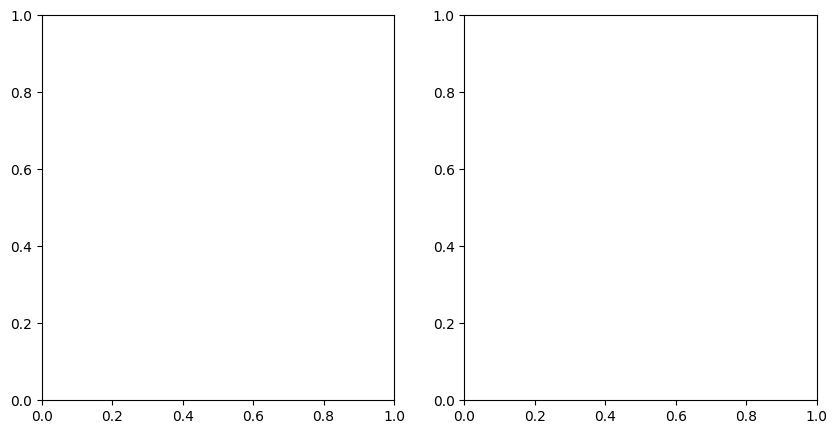

In [13]:
import matplotlib.pyplot as plt

# Plot original and transformed images
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axes[0].imshow(subject.t1.numpy()[0, :, :, subject.t1.shape[-1] // 2], cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(transformed_image.numpy()[0, :, :, transformed_image.shape[-1] // 2], cmap='gray')
axes[1].set_title('Transformed Image')
plt.show()
